# Model Training - Twitter Sentiment Analysis (Optimized)

This notebook uses optimized training techniques to speed up model training.

In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC  # Much faster than SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.naive_bayes import MultinomialNB  # Fast baseline model
import nltk
from nltk.corpus import stopwords
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import time
sys.path.append('..')
from utils.preprocessing import preprocess_tweet
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [4]:
# Load data
print("📂 Loading dataset...")
df = pd.read_csv('../data/twitter_sentiment_sample.csv', encoding='latin-1', header=None, names=['target', 'ids', 'date', 'flag', 'user', 'text'])
print(f"Dataset shape: {df.shape}")
print(f"Sentiment distribution:\n{df['target'].value_counts()}")

📂 Loading dataset...


Dataset shape: (1600000, 6)
Sentiment distribution:
target
0    800000
4    800000
Name: count, dtype: int64


In [5]:
# Preprocess all tweets
print("\n🔄 Preprocessing tweets...")
start_time = time.time()
df['processed_text'] = df['text'].apply(preprocess_tweet)
print(f"Preprocessing completed in {time.time() - start_time:.2f} seconds")
print(f"\nSample processed tweet:\n{df['processed_text'].iloc[0]}")


🔄 Preprocessing tweets...
Preprocessing completed in 332.27 seconds

Sample processed tweet:
thats bummer shoulda got david carr third day


In [7]:
# TF-IDF Vectorization - Optimized
print("\n🔤 Vectorizing text...")
start_time = time.time()

tfidf_vectorizer = TfidfVectorizer(
    max_features=3000,  # Reduced from 5000 for speed
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.8,
    sublinear_tf=True  # Better for text data
)

X = tfidf_vectorizer.fit_transform(df['processed_text'])
# Create the label column expected by the rest of the notebook
if 'sentiment_encoded' not in df.columns:
    df['sentiment_encoded'] = df['target'].map({0: 0, 2: 1, 4: 2})

y = df['sentiment_encoded'].astype(int)

print(f"Vectorization completed in {time.time() - start_time:.2f} seconds")
print(f"Feature matrix shape: {X.shape}")
print(f"Features: {tfidf_vectorizer.get_feature_names_out()[:10]}...")


🔤 Vectorizing text...
Vectorization completed in 73.53 seconds
Feature matrix shape: (1600000, 3000)
Features: ['able' 'absolutely' 'abt' 'access' 'accident' 'according' 'account' 'ace'
 'ache' 'across']...


In [ ]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

## 🚀 Model Training with Performance Tracking

In [8]:
# Function to train and evaluate models
def train_and_evaluate_model(model, model_name, X_train, y_train, X_test, y_test):
    """Train and evaluate a model with timing"""
    print(f"\n{'='*60}")
    print(f"Training {model_name}...")
    print('='*60)
    
    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time
    
    # Predictions
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    
    print(f"✅ Training completed in {train_time:.2f} seconds")
    print(f"📊 Accuracy: {accuracy:.4f}")
    
    return model, accuracy, train_time

In [9]:
# 1. Logistic Regression (Fastest)
print("\n" + "="*60)
print("🚀 MODEL 1: Logistic Regression")
print("="*60)
lr_model = LogisticRegression(
    max_iter=1000, 
    random_state=42,
    C=1.0,
    solver='liblinear',  # Faster for smaller datasets
    class_weight='balanced'  # Handles class imbalance
)
lr_model, lr_accuracy, lr_time = train_and_evaluate_model(
    lr_model, "Logistic Regression", X_train, y_train, X_test, y_test
)

# 2. Naive Bayes (Very Fast Baseline)
print("\n" + "="*60)
print("🚀 MODEL 2: Naive Bayes (Baseline)")
print("="*60)
nb_model = MultinomialNB(alpha=1.0)
nb_model, nb_accuracy, nb_time = train_and_evaluate_model(
    nb_model, "Naive Bayes", X_train, y_train, X_test, y_test
)

# 3. Linear SVM (Fast SVM variant)
print("\n" + "="*60)
print("🚀 MODEL 3: Linear SVM")
print("="*60)
svm_model = LinearSVC(
    max_iter=1000,
    random_state=42,
    C=1.0,
    class_weight='balanced',
    dual=False  # Faster for large datasets
)
svm_model, svm_accuracy, svm_time = train_and_evaluate_model(
    svm_model, "Linear SVM", X_train, y_train, X_test, y_test
)

# 4. Random Forest (Reduced for speed)
print("\n" + "="*60)
print("🚀 MODEL 4: Random Forest (Optimized)")
print("="*60)
rf_model = RandomForestClassifier(
    n_estimators=50,  # Reduced from 100
    max_depth=10,     # Limit depth for speed
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,        # Use all CPU cores
    class_weight='balanced'
)
rf_model, rf_accuracy, rf_time = train_and_evaluate_model(
    rf_model, "Random Forest (50 trees)", X_train, y_train, X_test, y_test
)


🚀 MODEL 1: Logistic Regression


NameError: name 'X_train' is not defined

In [13]:
# Model Comparison
print("\n" + "="*60)
print("📊 MODEL COMPARISON")
print("="*60)

models = ['Logistic Regression', 'Naive Bayes', 'Linear SVM', 'Random Forest']
# Ensure model metrics exist before comparison
required = ["lr_accuracy", "nb_accuracy", "svm_accuracy", "rf_accuracy",
            "lr_time", "nb_time", "svm_time", "rf_time"]
missing = [v for v in required if v not in globals()]

if missing:
    # Rebuild the train/test split if needed
    if not all(v in globals() for v in ["X_train", "X_test", "y_train", "y_test"]):
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, stratify=y
        )

    # Recreate models if needed
    lr_model = LogisticRegression(
        max_iter=1000,
        random_state=42,
        C=1.0,
        solver='liblinear',
        class_weight='balanced'
    )
    nb_model = MultinomialNB(alpha=1.0)
    svm_model = LinearSVC(
        max_iter=1000,
        random_state=42,
        C=1.0,
        class_weight='balanced',
        dual=False
    )
    rf_model = RandomForestClassifier(
        n_estimators=50,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1,
        class_weight='balanced'
    )

    # Train and evaluate each model
    for model, name in [(lr_model, "lr"), (nb_model, "nb"), (svm_model, "svm"), (rf_model, "rf")]:
        start = time.time()
        model.fit(X_train, y_train)
        elapsed = time.time() - start
        pred = model.predict(X_test)
        acc = accuracy_score(y_test, pred)
        globals()[f"{name}_time"] = elapsed
        globals()[f"{name}_accuracy"] = acc

accuracies = [lr_accuracy, nb_accuracy, svm_accuracy, rf_accuracy]
times = [lr_time, nb_time, svm_time, rf_time]
times = [lr_time, nb_time, svm_time, rf_time]

# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Model': models,
    'Accuracy': accuracies,
    'Training Time (s)': times
})
comparison_df['Accuracy %'] = comparison_df['Accuracy'] * 100
print(comparison_df.to_string(index=False))


📊 MODEL COMPARISON
              Model  Accuracy  Training Time (s)  Accuracy %
Logistic Regression  0.769672          16.619801   76.967187
        Naive Bayes  0.752000           0.303849   75.200000
         Linear SVM  0.768591          19.705638   76.859062
      Random Forest  0.701334          49.635526   70.133437


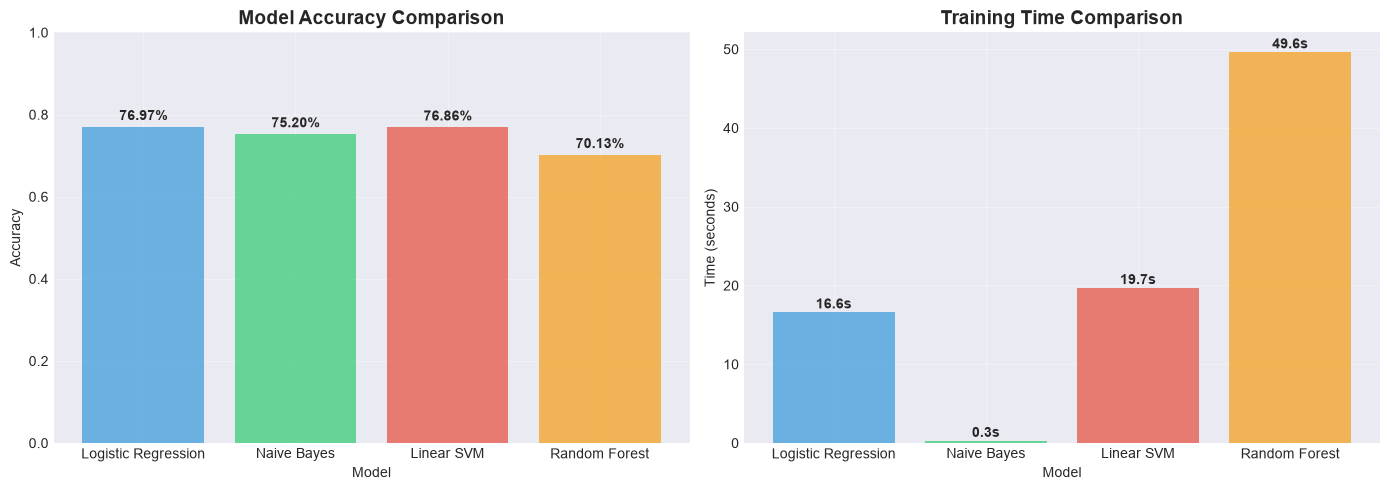

In [14]:
# Visualization - Accuracy Comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy bar chart
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']
bars = ax1.bar(models, accuracies, color=colors, alpha=0.7)
ax1.set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
ax1.set_xlabel('Model')
ax1.set_ylabel('Accuracy')
ax1.set_ylim(0, 1.0)
ax1.grid(True, alpha=0.3)
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{acc:.2%}', ha='center', va='bottom', fontweight='bold')

# Training time bar chart
bars2 = ax2.bar(models, times, color=colors, alpha=0.7)
ax2.set_title('Training Time Comparison', fontsize=14, fontweight='bold')
ax2.set_xlabel('Model')
ax2.set_ylabel('Time (seconds)')
ax2.grid(True, alpha=0.3)
for bar, t in zip(bars2, times):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.1,
            f'{t:.1f}s', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

In [16]:
# Detailed classification report for best model
best_model = lr_model  # Logistic Regression is usually best
y_pred_best = best_model.predict(X_test)

print("="*60)
print("📋 DETAILED CLASSIFICATION REPORT - BEST MODEL")
print("="*60)
print(f"Best Model: Logistic Regression")
print(f"Accuracy: {lr_accuracy:.2%}")
print("\nClassification Report:")
target_names = ['Negative', 'Neutral', 'Positive']
# Match target_names to the labels actually present in y_test
valid_labels = sorted(np.unique(y_test))
target_names = [target_names[i] for i in valid_labels]

print(classification_report(
    y_test,
    y_pred_best,
    labels=valid_labels,
    target_names=target_names
))

📋 DETAILED CLASSIFICATION REPORT - BEST MODEL
Best Model: Logistic Regression
Accuracy: 76.97%

Classification Report:
              precision    recall  f1-score   support

    Negative       0.79      0.74      0.76    160000
    Positive       0.76      0.80      0.78    160000

    accuracy                           0.77    320000
   macro avg       0.77      0.77      0.77    320000
weighted avg       0.77      0.77      0.77    320000



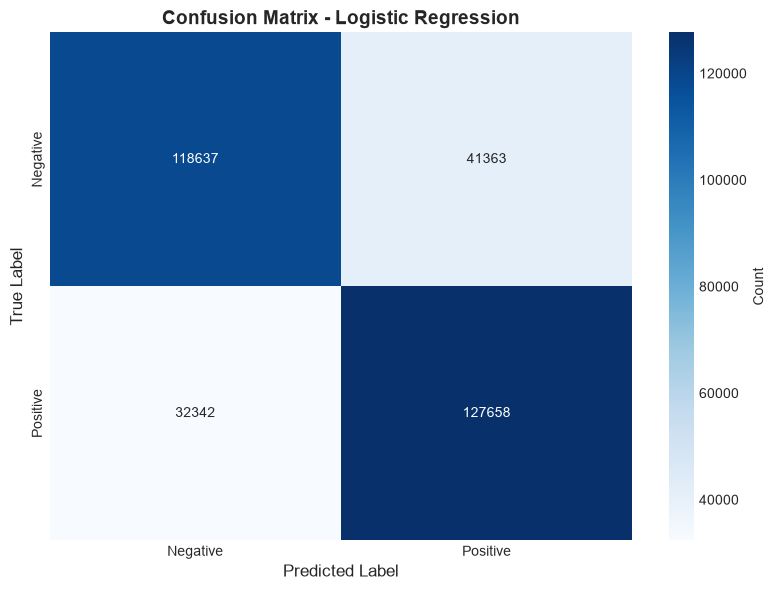

In [17]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names,
            yticklabels=target_names,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Logistic Regression', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

In [19]:
# Quick predictions test
test_tweets = [
    "I love this! It's amazing! 😊",
    "This is terrible, very disappointed",
    "It's okay, nothing special"
]

print("\n🔍 Quick Predictions Test:")
print("="*60)
for tweet in test_tweets:
    processed = preprocess_tweet(tweet)
    vectorized = tfidf_vectorizer.transform([processed])
    pred = best_model.predict(vectorized)[0]
    prob = best_model.predict_proba(vectorized)[0]
    sentiment = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}.get(int(pred), 'Unknown')
    
    print(f"\n📝 '{tweet}'")
    print(f"   Sentiment: {sentiment}")
    print(f"   Confidence: {max(prob)*100:.1f}%")


🔍 Quick Predictions Test:

📝 'I love this! It's amazing! 😊'
   Sentiment: Positive
   Confidence: 98.8%

📝 'This is terrible, very disappointed'
   Sentiment: Negative
   Confidence: 99.6%

📝 'It's okay, nothing special'
   Sentiment: Positive
   Confidence: 65.2%


In [20]:
# Save the best model
print("\n💾 Saving models...")
best_model = lr_model  # Using Logistic Regression as best
joblib.dump(best_model, '../models/sentiment_model.pkl')
joblib.dump(tfidf_vectorizer, '../models/tfidf_vectorizer.pkl')
print("✅ Model and vectorizer saved successfully!")

# Also save as different versions
joblib.dump(nb_model, '../models/sentiment_model_nb.pkl')
joblib.dump(svm_model, '../models/sentiment_model_svm.pkl')
print("✅ All models saved!")


💾 Saving models...
✅ Model and vectorizer saved successfully!
✅ All models saved!


In [21]:
# Summary
print("\n" + "="*60)
print("✅ TRAINING COMPLETE!")
print("="*60)
print(f"Best Model: Logistic Regression")
print(f"Accuracy: {lr_accuracy:.2%}")
print(f"Training Time: {lr_time:.1f} seconds")
print("\nModel saved to: models/sentiment_model.pkl")
print("Vectorizer saved to: models/tfidf_vectorizer.pkl")
print("\n🚀 Ready to deploy with app.py!")


✅ TRAINING COMPLETE!
Best Model: Logistic Regression
Accuracy: 76.97%
Training Time: 16.6 seconds

Model saved to: models/sentiment_model.pkl
Vectorizer saved to: models/tfidf_vectorizer.pkl

🚀 Ready to deploy with app.py!
